### DATASET: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

#### Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents

### Exploration and Data Loading

In [1]:
#%pip install pandas
#%pip install seaborn
#%pip install matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read in data and see how many rows & columns it has
df = pd.read_csv('/Users/R4G/Desktop/ML&DSProjects/Telco_Customer_Churn_Model/data/raw/Raw-Telco-Customer-Churn-Dataset.csv')
df.shape

(7043, 21)

In [3]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)  # Show all rows in the DataFrame
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Investigate data using the '.describe()' method
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Based on the .decribe() method, we can see a few things:
- Take a look at the "unique" column. For most categorical variables, they have between 2-4 categories
- For those that are binary (i.e., they have a 2 in the "unique" column), we can just replace them with 0 and 1--makes it easier for later!
- For those that have multiple classes (i.e., 3 or 4), we can use One-Hot encoding

### Binary Encoding

In [5]:
# For binary categorical columns (those with 2 in the "unique" column)
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Remove whitespace
df[binary_columns] = df[binary_columns].apply(lambda col: col.str.strip())

# Map the different values they could be to 0/1
df[binary_columns] = df[binary_columns].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

# Force dtype to int
df[binary_columns] = df[binary_columns].astype('int64')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### One-Hot Encoding

In [7]:
# For multiple categorical columns (those with > 2 in the "unique" column)
multiple_cat_columns = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# Perform one-hot encoding on those columns
df = pd.get_dummies(df, columns=multiple_cat_columns, drop_first=True)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

### More Cleaning

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Convert TotalCharges column to be numeric

In [10]:
df = df.drop('customerID', axis=1)  # Drop the customer ID feature because it's not really relevant to customer churn rate

In [11]:
bool_columns = df.select_dtypes(include='bool').columns  # Get columns that have boolean values
df[bool_columns] = df[bool_columns].astype(int)  # Converts True/False values to 1/0

In [12]:
df.info()  # We can see that all the features are now numerical

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

In [13]:
# See the correlation between 'Churn' and all other variables
correlation_matrix = df.corr(numeric_only=True)
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


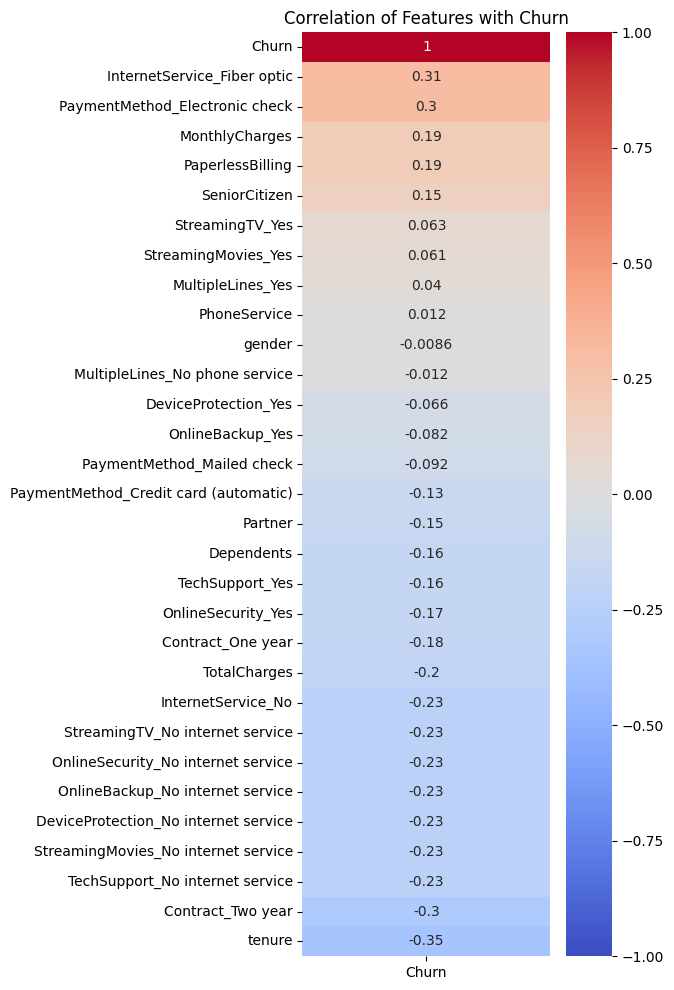

In [14]:
# Compute correlation matrix only for numeric columns
correlation_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = correlation_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot a heatmap that visually shows you how correlated other variables are to Churn
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

Some things to note here:

Negative values (the lower the value → less likely to churn)
- Tenure (-0.35) → Customers who stay longer are less likely to churn
- Contract_Two year (-0.3) → Customers who have two years on their contract are less likely to churn
- Contract_One year (-0.18) → Customers who have one year on their contract are less likely to churn, but not as much as the previous two variables

Positive values (the higher the value → more likely to churn)
- InternetService_Fiber optic (+0.31) → Fiber optic users are more likely to churn
- PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check are more likely to churn

### Checking for Multicollinearity (VIF)

Multicollinearity is a statistical phenomenon where two or more independent variables are highly correlated, meaning they contain similar information. It's important to check for this because reducing the number of multicollinear variables makes our model less redundant. It makes it difficult for the model to isolate the individual effect of each predictor on the dependent variable if there are many multicollinear features.

To check this, we will use the Variance Inflation Factor (VIF). VIF measures how much variance of an estimated regression coefficient increases due to collinearity with other predictors. VIF values greater or equal to 5 or 10 indicate high multicollinearity.

In [15]:
# Before running VIF, collapse redundant columns
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop original redundant dummy columns
drop_columns = [column for column in df.columns if 'No internet service' in column]
df = df.drop(columns=drop_columns)

# Handle PhoneService redundancy 
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [16]:
# Prepare X data
X = df.drop(columns=['Churn'])
bool_columns = X.select_dtypes(include='bool').columns
X[bool_columns] = X[bool_columns].astype(int)

In [17]:
# Run VIF

#%pip install statsmodels

from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF value'] = [variance_inflation_factor(X.values, counter) for counter in range(X.shape[1])]  # Calculates the VIF for each column in the data
vif_data = vif_data.sort_values(by='VIF value', ascending=False)

print(vif_data)

C:\Users\R4G\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature    VIF value
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

From the results above, we can clearly see that there is multicollinearity between features. To address this, we can either drop some features or use regularization techniques (e.g., Lasso, Ridge regression) to handle it. We can also use tree based models (e.g., decision trees), which are naturally less sensitive to multicollinearity; this is because in decision trees, splits are based on feature importance for reducing impurity.

For this project, we'll use tree-based models to address multicollinearity.

### Start of Machine Learning

In [18]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

From the above code snippet, we can see we have a class imbalance problem. To deal with it, we can use a combination of class weighting + threshold tuning.

In churn prediction, recall is usually the most important. Recall essentially asks *"Of all real positive cases, how many are predicted positive?"* This differs from precision, where the question is *"Of all positive predictions, how many are really positive?"*

Recall is important because:

1. In business contexts, churn prediction is asymmetric in cost
    - False Negatives (FN): You predict a customer will not churn, but they actually do → You miss out on the opportunity to keep them
    - False Positive (FP): You predict a customer will churn, but they don't → You might spend unnecessary resources to keep them
    - False negatives usually cost more than wrongly targeting a loyal customer <br><br>

2. It affects priority
    - If retention campaigns are cheap → prioritize recall (i.e., catch every possible churner)
    - If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off
    - If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model

In [19]:
#%pip install scikit-learn
#%pip install lightgbm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

# Prepare X and y data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

THRESHOLD = 0.3  # Set to < 0.5 to boost recall; makes the model more sensitive, helping it catch more positive cases, even if it increases FPs 

#### 1️⃣ RandomForest Classifier

In [20]:
# Set hyperparameters for a random forest model
randomforest = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',  # Handles the class imbalance we discussed earlier
    random_state=42,
    n_jobs=-1
)

# Train the rf model on our data
randomforest.fit(X_train, y_train)

# Calculate/get predictions
probabilities = randomforest.predict_proba(X_test)[:, 1]  # Only getting the second column because that corresponds to probabilities of the positive class (i.e., churning customers) 
#print(probabilities)
y_preds = (probabilities >= THRESHOLD).astype(int)  # Only return True/1 if probabilities exceed threshold

# Display classification report
print(classification_report(y_test, y_preds, digits=3))


              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

probabilities = randomforest.predict_proba(X_test)[:, 1]

print("THRESHOLD TUNING FOR RandomForest:\n")

print(f"{'Thres':<8}{'Prec':<8}{'Rec':<8}{'F1':<8}")
for thres in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thres).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)  # 'pos_label=1' explicitly defines class 1 as the positive class
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thres:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

THRESHOLD TUNING FOR RandomForest:

Thres   Prec    Rec     F1      
0.25    0.508   0.797   0.620   
0.3     0.531   0.717   0.610   
0.35    0.548   0.668   0.602   
0.4     0.571   0.615   0.592   
0.45    0.601   0.551   0.575   
0.5     0.625   0.489   0.549   


Even though we want to prioritize recall, it's also important to make sure there's a balance between that and precision. Even though threshold=0.25 has the best recall, the precision decreases quite a bit compared to when threshold=0.30. 

For our purposes, let's just take the recall to be 71.7% (i.e., when threshold=0.30) → We are catching 71.7% of actual churners with RandomForest

#### 2️⃣ LightGBM Classifier

In [22]:
from lightgbm import LGBMClassifier

# Set hyperparameters for an lgbm model
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Time how long it takes to train the model
start_training_time = time.time()
lgbm.fit(X_train, y_train)
training_time = time.time() - start_training_time
print(f"\n⏱ Training time: {training_time:.2f} seconds")

# Time how long it takes to make predictions
start_pred_time = time.time()
probabilities = lgbm.predict_proba(X_test)[:, 1]
y_preds = (probabilities >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred_time
print(f"⏱ Prediction time: {pred_time:.4f} seconds\n")

# Display classification report
print(classification_report(y_test, y_preds, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

⏱ Training time: 0.92 seconds
⏱ Prediction time: 0.0180 seconds

              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.

Again, we are focusing on recall. Take a look at it: the results have gone up to 81.8%! This is an improvement from the random forest model we had.

If retention offers are at a low-cost, then the drop-off in precision is fine. 

In [23]:
probabilities = lgbm.predict_proba(X_test)[:, 1]

print("THRESHOLD TUNING FOR LightGBM\n")

print(f"{'Thres':<8}{'Prec':<8}{'Rec':<8}{'F1':<8}")
for thres in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thres).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thres:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

THRESHOLD TUNING FOR LightGBM

Thres   Prec    Rec     F1      
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


Like with the RandomForest classifier, we can also perform threshold tuning and see which results are best depending on the threshold we choose.

Again, we have to look at the trade-off between precision and recall. For our purposes, we may actually take the recall when threshold=0.25 because the drop-off for precision between threshold=0.25 and threshold=0.30 isn't *too* significant.

#### 3️⃣ XGBoost Classifier

In [24]:
#%pip install xgboost

from xgboost import XGBClassifier

# Calculate the scale_pos_weight for class imbalance
# scale_pos_weight is the ratio of the negative class to the positive class, and its purpose is to allow the algorithm to
# give more importance to the minority class (in this case, the positive class, churn) during training
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Set hyperparameters for the XGBoost classifier
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,  # Randomly sample 80% of the training data before growing each tree, adding randomness to make training more robust to noise
    colsample_bytree=0.8,  # 80% of the features will be randomly sampled for each tree constructed
    random_state=42,
    n_jobs=-1,  # Utilize all available CPU cores to speed up training
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'  # Sets evaluation metric to log loss; standard for binary classification tasks
)

# Time how long it takes to train the model
start_training_time = time.time()
xgb.fit(X_train, y_train)
training_time = time.time() - start_training_time
print(f"\n⏱ Training time: {training_time:.2f} seconds")

# Time how long it takes to make predictions
start_pred_time = time.time()
probabilities = xgb.predict_proba(X_test)[:, 1]
y_preds = (probabilities >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred_time
print(f"⏱ Prediction time: {pred_time:.4f} seconds\n")

# Display classification report
print(classification_report(y_test, y_preds, digits=3))


⏱ Training time: 1.26 seconds
⏱ Prediction time: 0.0288 seconds

              precision    recall  f1-score   support

           0      0.914     0.681     0.781      1035
           1      0.483     0.824     0.609       374

    accuracy                          0.719      1409
   macro avg      0.699     0.752     0.695      1409
weighted avg      0.800     0.719     0.735      1409



If we compare the recall here to the RandomForest and LGBM classifiers, we see that it's an improvement.

In [25]:
probabilities = xgb.predict_proba(X_test)[:, 1]

print("THRESHOLD TUNING FOR XGBoost\n")

print(f"{'Thres':<8}{'Prec':<8}{'Rec':<8}{'F1':<8}")
for thres in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thres).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thres:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

THRESHOLD TUNING FOR XGBoost

Thres   Prec    Rec     F1      
0.25    0.467   0.845   0.602   
0.3     0.483   0.824   0.609   
0.35    0.504   0.794   0.617   
0.4     0.520   0.770   0.621   
0.45    0.536   0.741   0.622   
0.5     0.551   0.698   0.616   


When doing thresholding tuning, we can see that when threshold=0.25 or 0.30, it contains the best recall. This is not surprising because this was similar to our results for random forest and LGBM. 

We could take the recall when threshold=0.25 or 0.30. It all depends on how important the drop-off in precision is to us. In a real-world context, this would be something we'd discuss with shareholders or other members of the team. For our purposes, we could just take the recall when the threshold is at 0.25.

#### Conclusions About Various Models

For our purposes, let's chose **XGBoost.** This is because out of all our models, it was the one that got the highest recall value. It also trained in around the same time as LightGBM, so there's no incentive (as of now) to use LightGBM or RandomForest over it.

### Hyperparemeter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [26]:
#%pip install optuna

import optuna

# Test out different values for the various hyperparameters for XGBoost
def objective(trial):
    """
    Objective function for Optuna. Tests out values for various hyperparameters for XGBoost.

    PARAMETERS:
        - trial: Object that represents a single trial that we're doing

    RETURNS:
        The recall score
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),  # Number of trees
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),  # Controls how fast the model learns
        "max_depth": trial.suggest_int("max_depth", 3, 10),  # Maximum depth of each tree
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),  # Fraction of training data used per tree
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # Fraction of features used per tree
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),  # Controls how easily the model splits nodes (higher --> more conservative splits)
        "gamma": trial.suggest_float("gamma", 0, 5),  # Minimum loss reduction required to make a split (higher --> fewer splits and simpler model)
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),  # Encourages sparsity (feature selection effect)
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),  # Penalizes large weights to help prevent overfitting
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),  # For class imbalance
        "eval_metric": "logloss"  # Log loss used as evaluation metric
    }

    model = XGBClassifier(**params)  # Create XGBoost classifier with the sampled parameters
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_test)[:, 1]
    y_preds = (probabilities >= THRESHOLD).astype(int)
    
    return recall_score(y_test, y_preds, pos_label=1)

# Run Optuna
study = optuna.create_study(direction='maximize')  # 'maximize' because a higher recall is better
study.optimize(objective, n_trials=30)  # Perform 30 trials; in each trial: pick hyperparams, train the model, calculate recall, keep track of best result

print("\nBest Params: ", study.best_params)
print("Best Recall Score: ", study.best_value)

[I 2026-04-15 11:10:57,349] A new study created in memory with name: no-name-15e5fcb3-5cc0-4bca-b282-53bde7c48b1d
[I 2026-04-15 11:10:57,882] Trial 0 finished with value: 0.9037433155080213 and parameters: {'n_estimators': 320, 'learning_rate': 0.09630660771652742, 'max_depth': 3, 'subsample': 0.6820863120174917, 'colsample_bytree': 0.8379164471692979, 'min_child_weight': 1, 'gamma': 1.1843962541585844, 'reg_alpha': 3.8210049055953688, 'reg_lambda': 4.906982750472988}. Best is trial 0 with value: 0.9037433155080213.
[I 2026-04-15 11:10:58,575] Trial 1 finished with value: 0.8636363636363636 and parameters: {'n_estimators': 440, 'learning_rate': 0.05427029369882738, 'max_depth': 5, 'subsample': 0.680372435669608, 'colsample_bytree': 0.687999531614065, 'min_child_weight': 7, 'gamma': 0.47347117445504294, 'reg_alpha': 0.7380106589316282, 'reg_lambda': 4.536735709634195}. Best is trial 0 with value: 0.9037433155080213.
[I 2026-04-15 11:10:59,138] Trial 2 finished with value: 0.898395721925


Best Params:  {'n_estimators': 564, 'learning_rate': 0.15696402401397386, 'max_depth': 3, 'subsample': 0.9986246355890553, 'colsample_bytree': 0.5958696180307819, 'min_child_weight': 6, 'gamma': 3.394676430034744, 'reg_alpha': 2.746092706767129, 'reg_lambda': 2.5587758439870694}
Best Recall Score:  0.9224598930481284


In the above code, we are testing out different values for various hyperparameters for the XGBoost algorithm. Optuna makes it easy to test out these different values and see their results. It also keeps track of the best hyperparameters and the best results, as we can see from the output.

The best recall is ~0.928, which looks really good!

In [27]:
# Calculate the scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and best parameters to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create XGBoost classifier with the best parameters
xgb = XGBClassifier(**best_params)

# Time how long it takes to train the model
start_training_time = time.time()
xgb.fit(X_train, y_train)
training_time = time.time() - start_training_time
print(f"\n⏱ Training time: {training_time:.2f} seconds")

# Time how long it takes to make predictions
start_pred_time = time.time()
probabilities = xgb.predict_proba(X_test)[:, 1]
y_preds = (probabilities >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred_time
print(f"⏱ Prediction time: {pred_time:.4f} seconds\n")

# Display classification report
print(classification_report(y_test, y_preds, digits=3))


⏱ Training time: 0.53 seconds
⏱ Prediction time: 0.0100 seconds

              precision    recall  f1-score   support

           0      0.951     0.548     0.695      1035
           1      0.424     0.922     0.581       374

    accuracy                          0.647      1409
   macro avg      0.688     0.735     0.638      1409
weighted avg      0.811     0.647     0.665      1409



Remember that when we initially did the XGBoost classifier, we got a recall score of 0.845. This was the recall when the threshold was at 0.25. Compare this to our recall now, 0.922. That is a +7.7% improvement! All of that is because we optimized the hyperparameters we were working with!

In [35]:
#%pip install mlflow

import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import roc_auc_score
from pathlib import Path
import os

# Force MLflow to always use the project root's mlruns folder
project_root = Path(os.getcwd()).parent()
mlruns_path = project_root / "mlruns"
mlflow.set_tracking_uri(mlruns_path.as_uri())
mlflow.set_experiment("Telco Churn - XGBoost")

with mlflow.start_run():
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Use the best parameters from Optuna
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    # Log params
    mlflow.log_params(best_params)

    # Create XGBoost classifier with the best parameters
    xgb = XGBClassifier(**best_params)
    
    # Time how long it takes to train the model
    start_training_time = time.time()
    xgb.fit(X_train, y_train)
    training_time = time.time() - start_training_time
    mlflow.log_metric("train_time", training_time)
    
    # Time how long it takes to make predictions
    start_pred_time = time.time()
    probabilities = xgb.predict_proba(X_test)[:, 1]
    y_preds = (probabilities >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred_time
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_preds, pos_label=1)
    recall = recall_score(y_test, y_preds, pos_label=1)
    f1 = f1_score(y_test, y_preds, pos_label=1)
    auc = roc_auc_score(y_test, probabilities)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.xgboost.log_model(xgb, "model")

    # Display classification report
    print(classification_report(y_test, y_preds, digits=3))

C:\Users\R4G\AppData\Roaming\Python\Python314\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/15 11:46:54 INFO mlflow.tracking.fluent: Experiment with name 'Telco Churn - XGBoost' does not exist. Creating a new experiment.
2026/04/15 11:46:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.951     0.548     0.695      1035
           1      0.424     0.922     0.581       374

    accuracy                          0.647      1409
   macro avg      0.688     0.735     0.638      1409
weighted avg      0.811     0.647     0.665      1409



To recap this section, we tuned XGBoost using Optuna, maximizing recall for churners.

- Recall: 0.922 (Highest we've seen so far)
- Precision: 0.424 (Low; in this context, it means that we are tagging many loyal customers as churners)
- F1: 0.581 (Low because this is a combination of recall & precision, and as we just saw, the precision itself is low)

Interpretation:
- The model is catching almost all churners, which is great if we're running aggressive retention campaigns and the cost of contacting non-churners is low
- However, the low precision means more than half of the people you target won't actually churn
- These trade-offs are things you ultimately need to discuss with shareholders and other members of the team